# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')

In [3]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [4]:
df_shape = df.shape
print(f"Набір даних містить {df_shape[0]} рядків та {df_shape[1]} колонок")

Набір даних містить 10886 рядків та 19 колонок


In [5]:
df.index.min()

Timestamp('2011-01-01 00:00:00')

In [6]:
df.index.max()

Timestamp('2012-12-19 23:00:00')

отже дані охоплюють період майже в 2 роки

In [7]:
df.index[:5]

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00'],
              dtype='datetime64[ns]', name='datetime', freq=None)

записи роблять щогодини

In [8]:
#diff().value_counts() - порахує скільки разів зустрічається кожна різниця між сусідніми timestamps

df.index.to_series().diff().value_counts()

datetime
0 days 01:00:00     10820
0 days 02:00:00        36
12 days 01:00:00       13
11 days 01:00:00        8
0 days 03:00:00         5
0 days 13:00:00         1
9 days 01:00:00         1
10 days 01:00:00        1
Name: count, dtype: int64

маємо 10820 щогодинних записів,
і також є пропуски в даних

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [9]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [10]:
rent_by_date = df.groupby("date")["count"].sum()
rent_by_date

date
2011-01-01     985
2011-01-02     801
2011-01-03    1349
2011-01-04    1562
2011-01-05    1600
              ... 
2012-12-15    5047
2012-12-16    3786
2012-12-17    4585
2012-12-18    5557
2012-12-19    5267
Name: count, Length: 456, dtype: int64

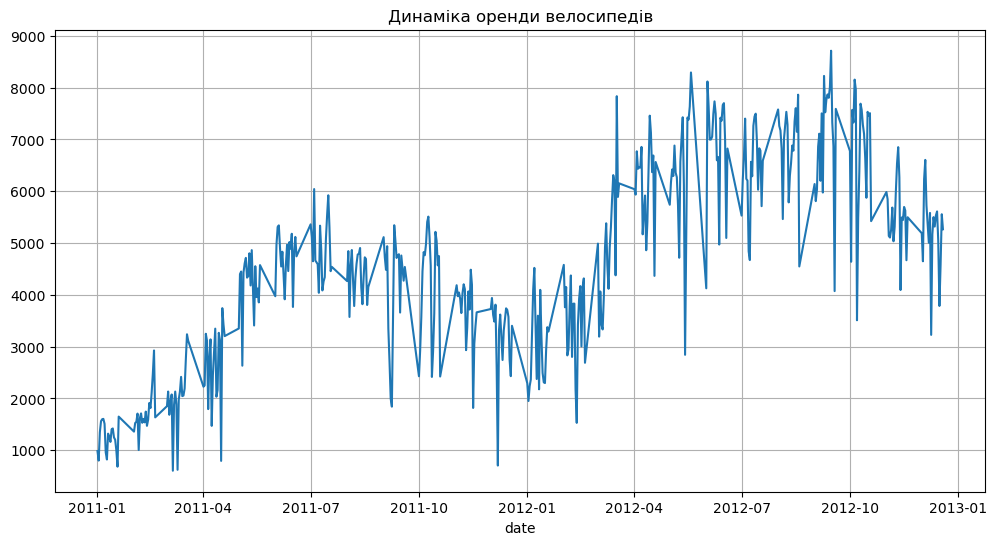

In [11]:
rent_by_date.plot(
    figsize=(12, 6),
    title="Динаміка оренди велосипедів",
    grid=True)
plt.savefig("rent_by_date.png", dpi=300, bbox_inches="tight")
plt.show()

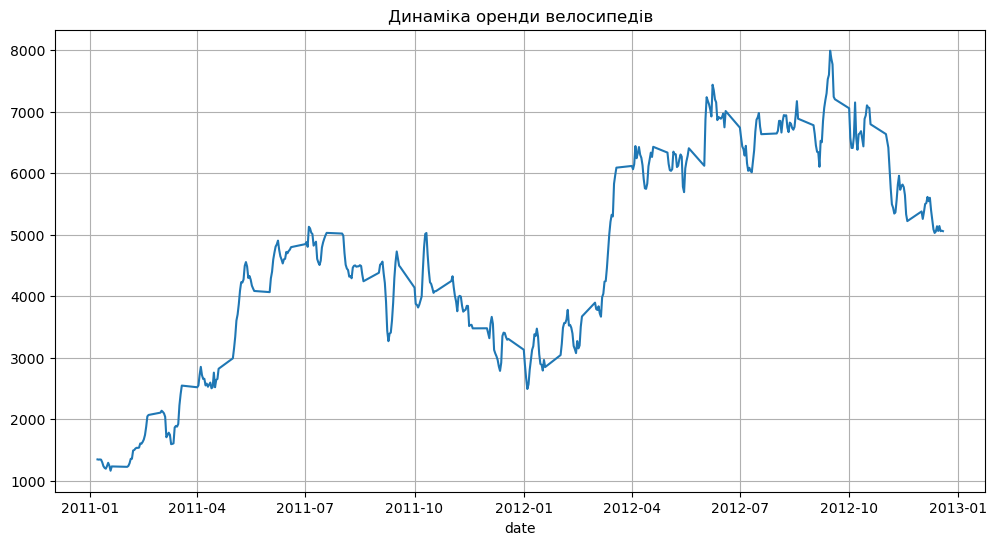

In [12]:
# прибрати заломи - згладжуванням:

rent_by_date.rolling(7).mean().plot(
    figsize=(12, 6),
    title="Динаміка оренди велосипедів",
    grid=True)
plt.savefig("rent_by_date.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# як погода впливає на оренду
# (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)

rent_by_weather = df.groupby("weather")["count"].mean()
rent_by_weather

weather
1    205.236791
2    178.955540
3    118.846333
4    164.000000
Name: count, dtype: float64

Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
Заломи - це можуть бути робочі/вихідні/святкові дні чи дні поганих погодних умов. Прибрати спробуємо згладжуванням

Які загальні тенденції ви бачите на графіку?
Загальна позитивна динаміка- кількість сеансів оренди зростає від початку 2011 і до кінця 2012. Чітко проглядається сезонність

Чи помітні якісь сезонні коливання?
одразу помітні - січень маю найнижчі показники, а квітень - листопад відображають підвищений попит на оренду.

Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?
найнижчі значення припадають на зимовий період в Індії, в інший час - всплеск користування

як погода впливає на оренду?
#weather - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
найбыльший попит бачимо в ясні дні (205), найменший - в дегкий дощ (118). це потребує глибшого розгляду


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [14]:
# створити колонку для індійських сезонів

season_india = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Summer', 4: 'Summer', 5: 'Summer',
              6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
              10: 'Post-Monsoon', 11: 'Post-Monsoon'}

df["weather_season_india"] = df["month"].map(season_india)
df[["month", "weather_season_india"]].head()

,month,weather_season_india
datetime,,
2011-01-01 00:00:00,1,Winter
2011-01-01 01:00:00,1,Winter
2011-01-01 02:00:00,1,Winter
2011-01-01 03:00:00,1,Winter
2011-01-01 04:00:00,1,Winter


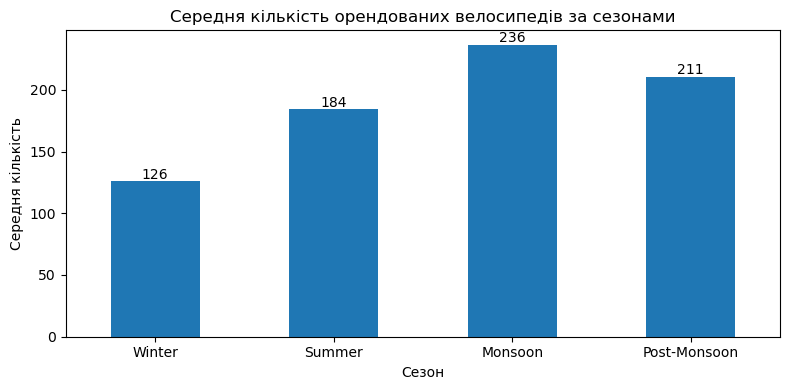

In [ ]:
rent_by_season = df.groupby("weather_season_india")["count"].mean()

order = ["Winter", "Summer", "Monsoon", "Post-Monsoon"]
rent_by_season = rent_by_season.reindex(order)

rent_by_season.plot.bar(
    figsize=(8, 4),
    # color='skyblue',
    title="Cередня кількість орендованих велосипедів за сезонами",
    ylabel="Середня кількість",
    xlabel="Сезон"
)

for i, v in enumerate(rent_by_season):
    plt.text(i, v + 2, f"{v:.0f}", ha="center")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("rent_by_season.png", dpi=300, bbox_inches="tight")
plt.show()

1. В який квартал найбільша середня кількість оренди велосипедів?
moonsoon

2. Як ви можете пояснити таку сезонну закономірність?
Winter - прохолодно
Summer - занадто спекотно
Monsoon - ідеальнй баланс відсутності спеки і наявної прохолоди породжує високий попит на велосипеди
Post-Monsoon - так само комфортна температура для катання, до настання холодів

3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?
майже вдвічі (236/126) = 1.8

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

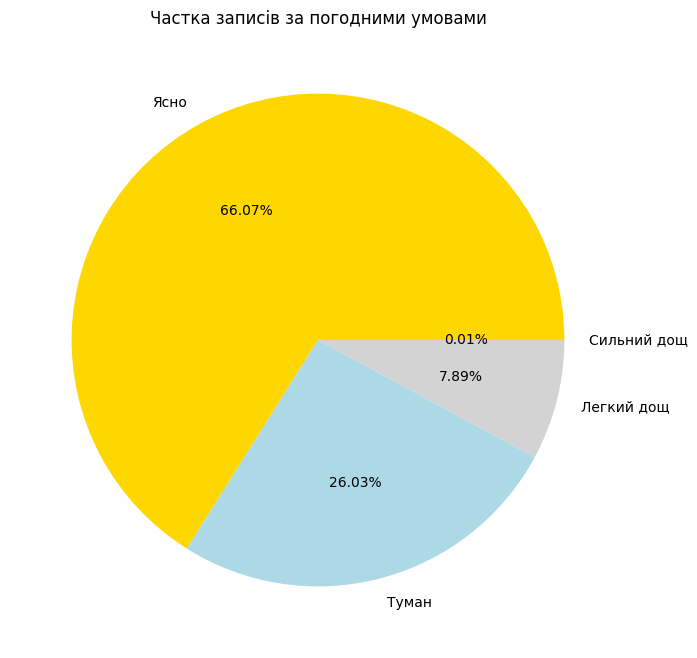

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?